
Loaded files:
S-M-06-int.csv
S-M-07-int.csv
S-M-11-int.csv
S-M-12-int.csv
S-M-14-int.csv
S-M-27-int.csv

NAIVE ONE-STEP FORECAST RESULTS: S-M-06-int
forecast_date  H_obs  H_forecast  H_error  BM_obs  BM_forecast  BM_error  BH_obs  BH_forecast  BH_error   L_obs  L_forecast  L_error
   2024-07-25    4.0         4.0      0.0  0.0000       0.0000    0.0000 10.0000       8.0000   -2.0000 10.0000         5.0      0.0
   2024-10-07    3.0         4.0      1.0  0.0175       0.0000   -0.0175  6.9825      10.0000    3.0175  6.9825         5.0      0.0
   2024-10-29    3.0         3.0      0.0  0.0150       0.0175    0.0025  5.9850       6.9825    0.9975  5.9850         5.0      0.0
   2024-11-05    4.0         3.0     -1.0  0.0600       0.0150   -0.0450  7.9400       5.9850   -1.9550  7.9400         5.0      1.0
   2024-11-14    4.0         4.0      0.0  0.0175       0.0600    0.0425  6.9825       7.9400    0.9575  6.9825         4.0     -2.0
   2024-12-09    7.0         4.0     -3.0  0.0625   

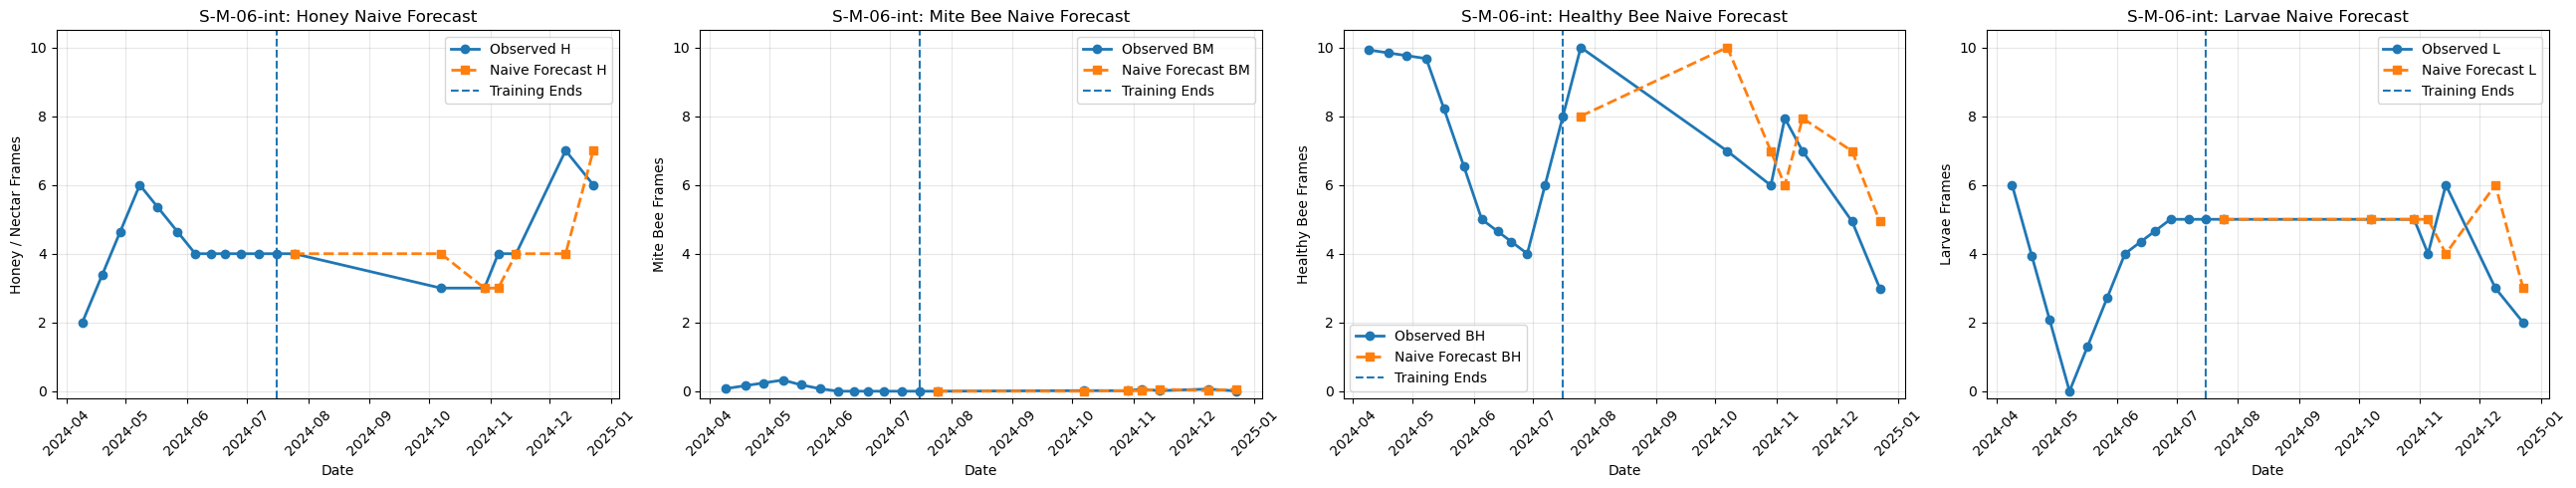

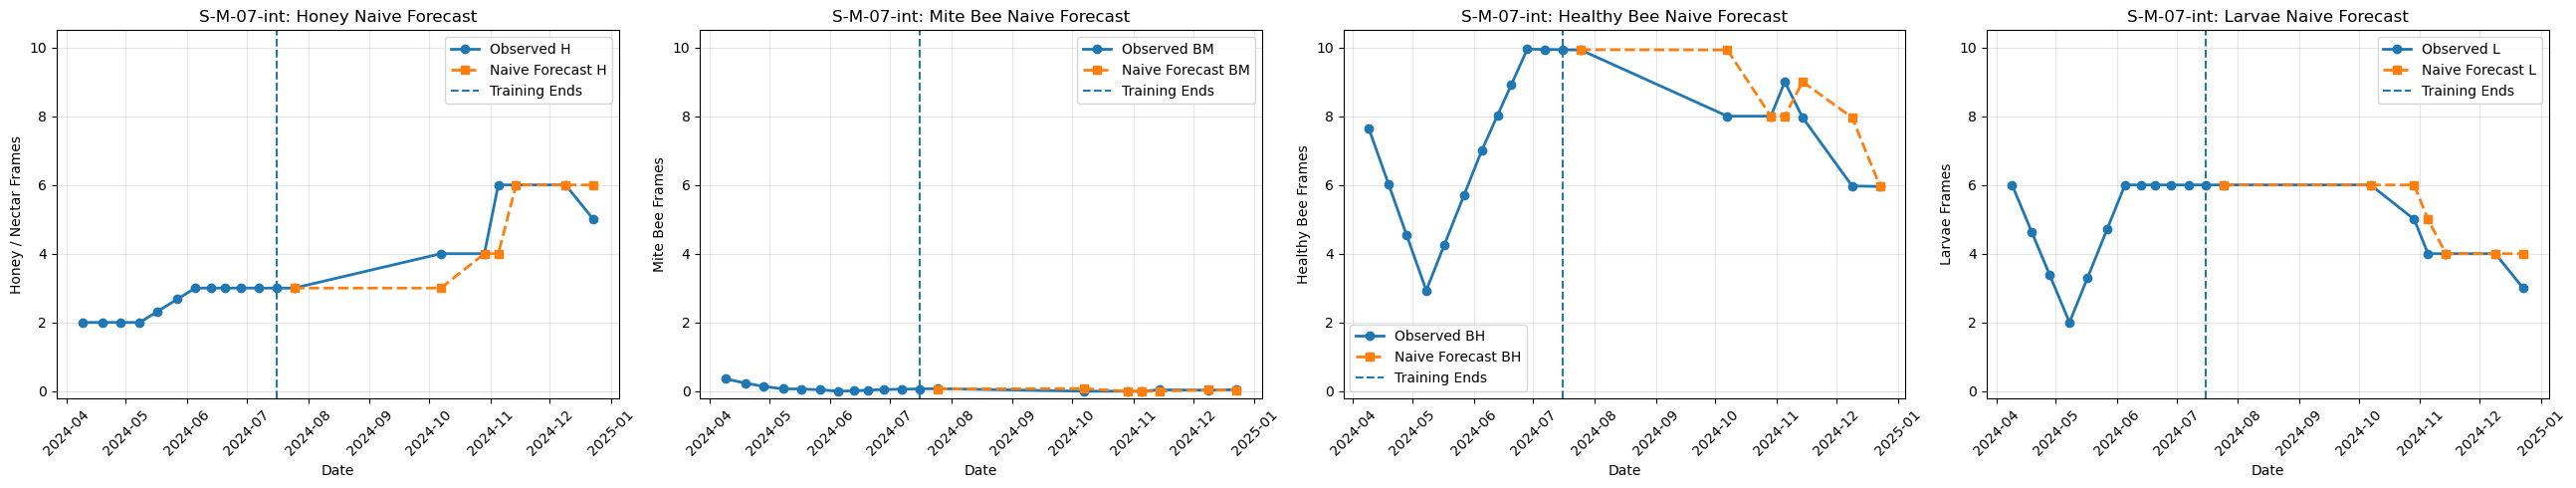

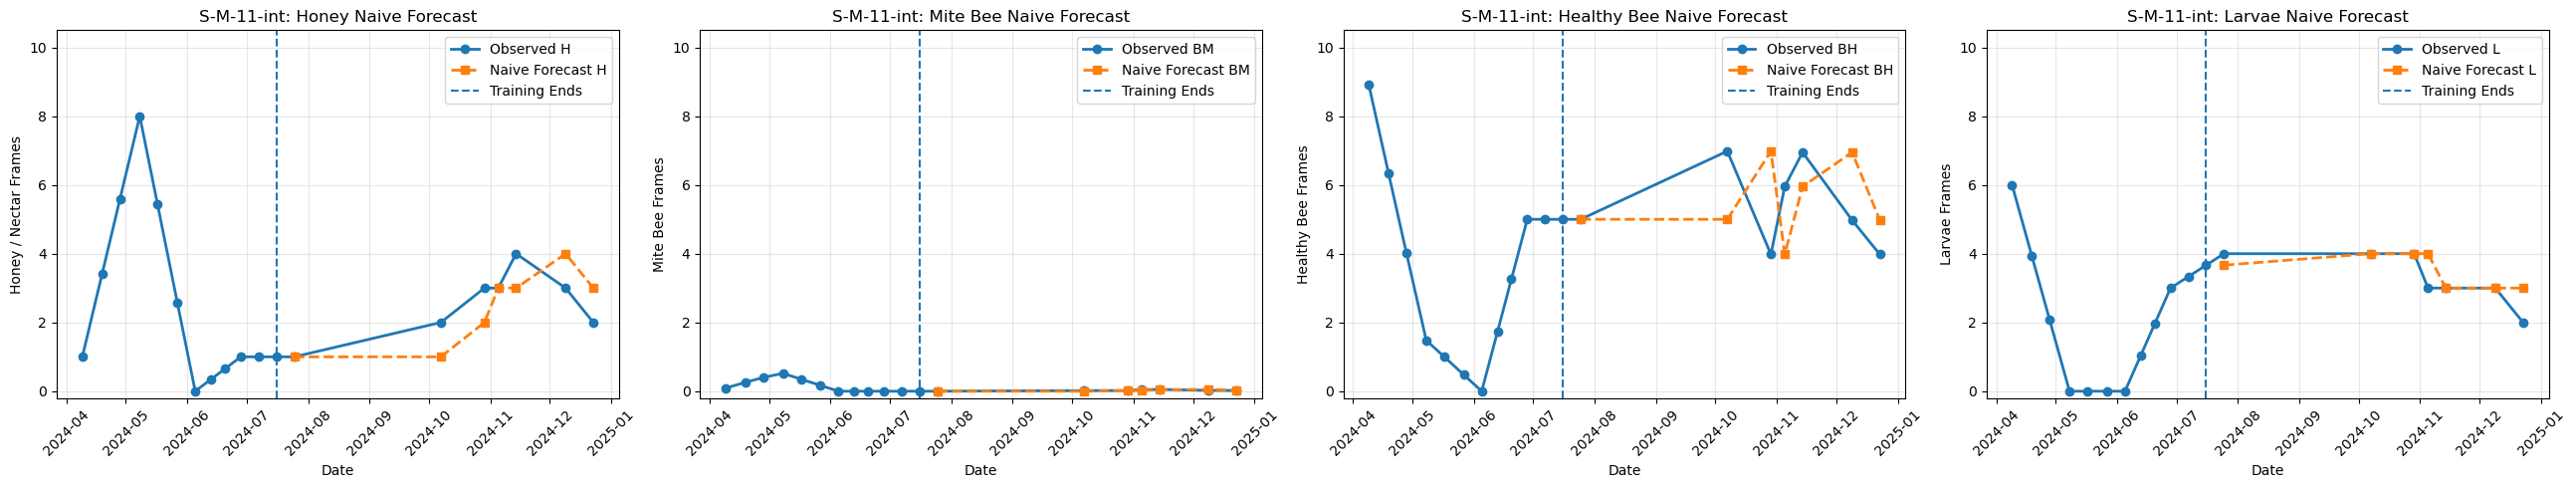

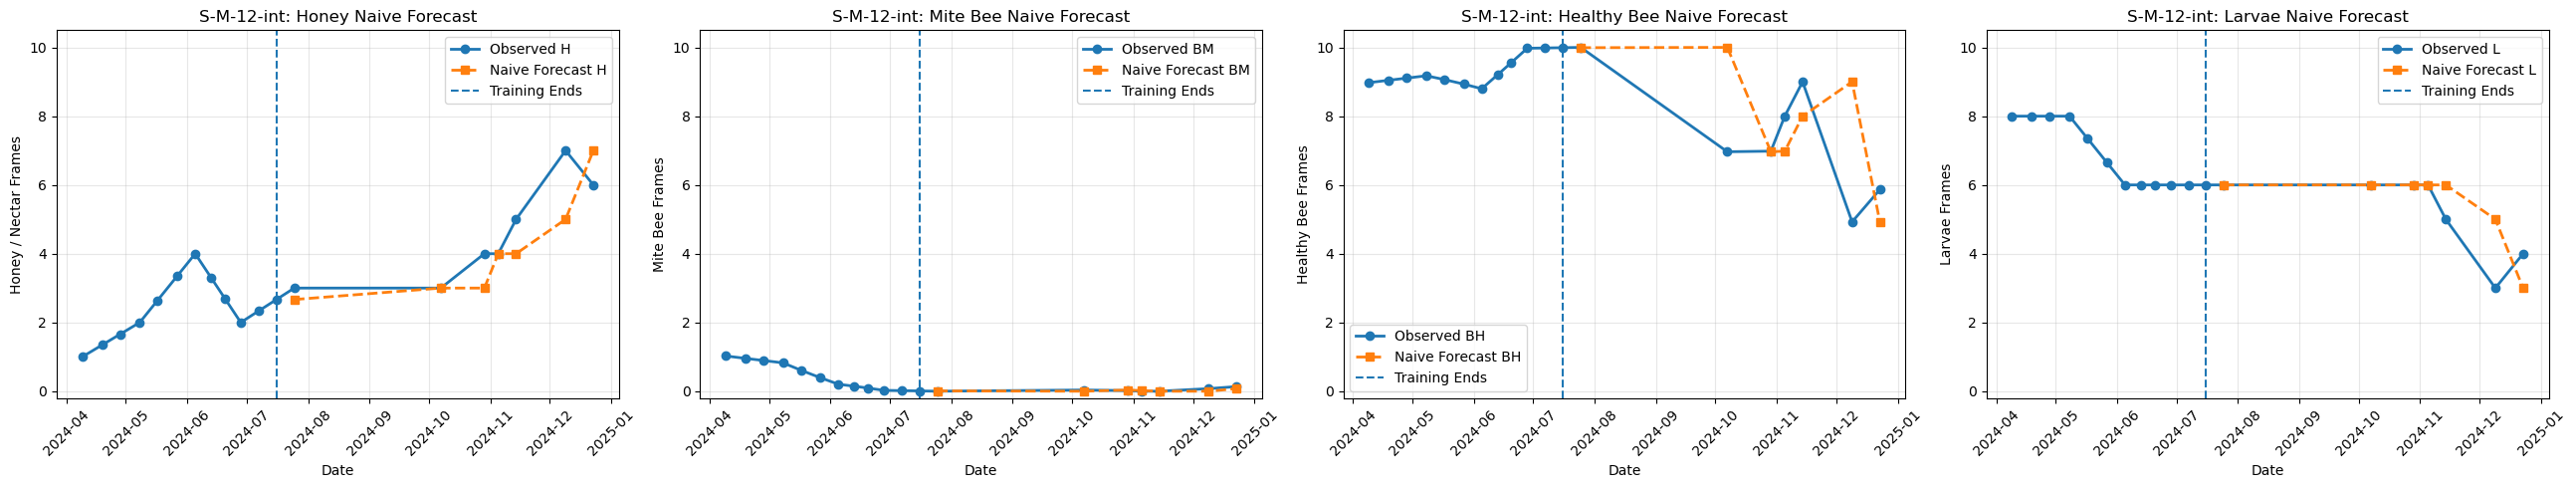

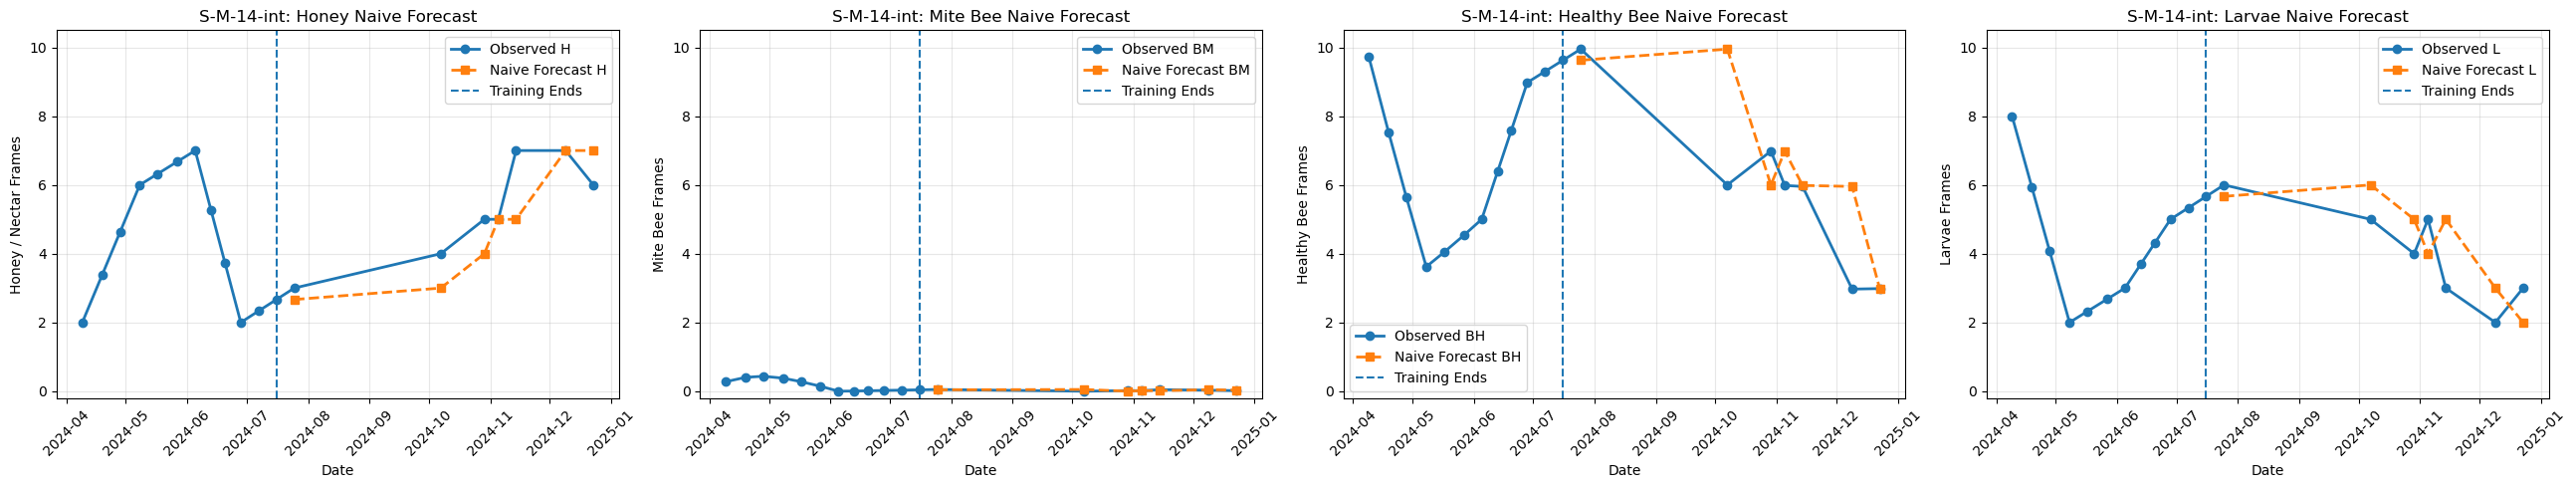

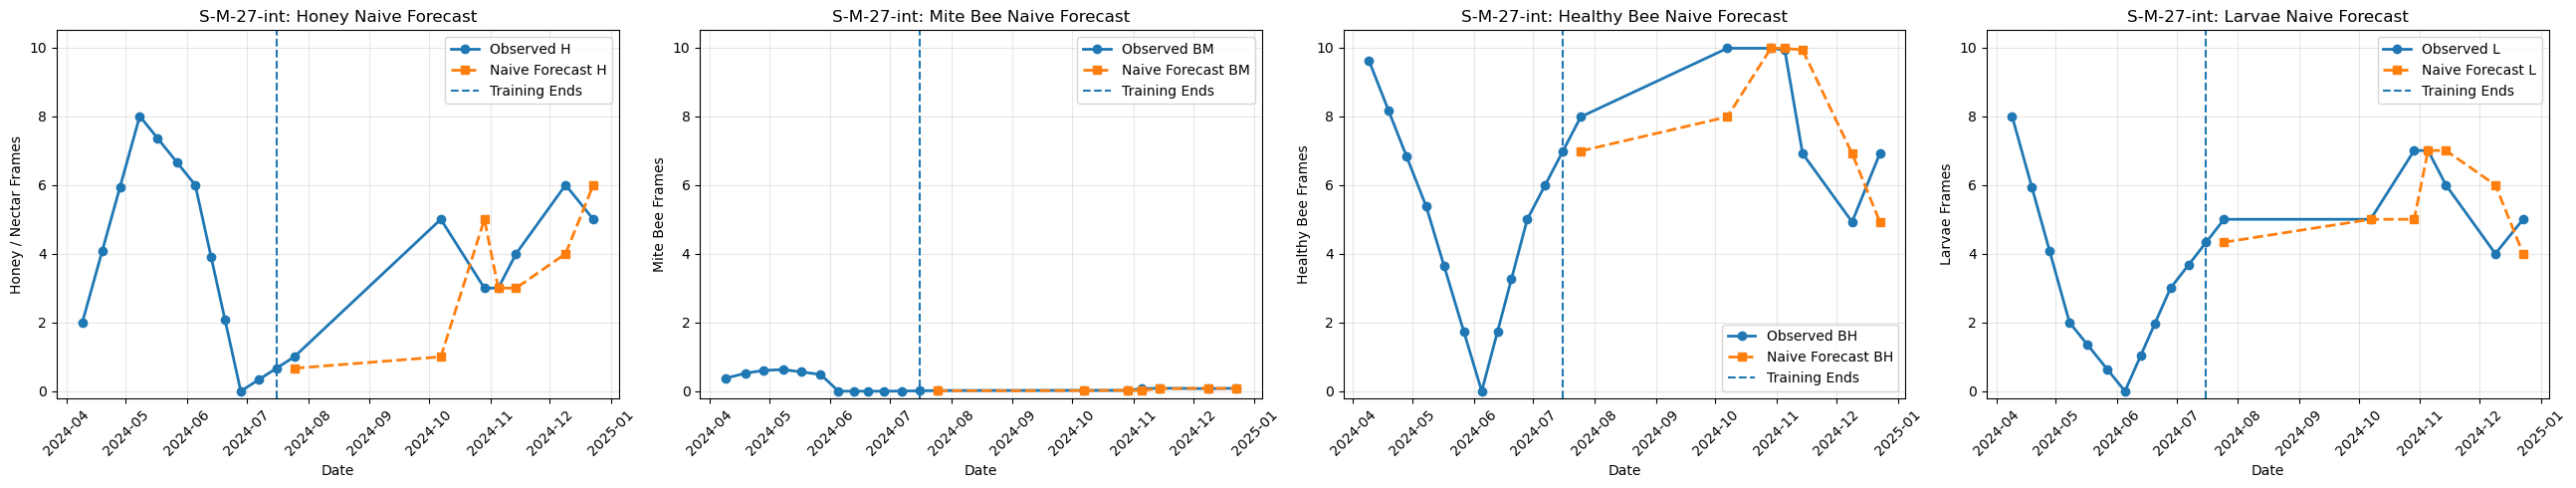

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
import pandas as pd
import glob
import os

# ============================================================
# SETTINGS
# ============================================================

DATA_FOLDER = r"C:\Bee Temp Data\S-M-train-int"

# ============================================================
# LOAD DATA
# ============================================================

csv_files = sorted(glob.glob(os.path.join(DATA_FOLDER, "*.csv")))

print("\nLoaded files:")
for f in csv_files:
    print(os.path.basename(f))

all_hives = []

for file in csv_files:
    data = pd.read_csv(file)
    data["Date"] = pd.to_datetime(data["Date"])

    H_obs = np.array(data["Nectar"], dtype=float)
    L_obs = np.array(data["Frames Brood"], dtype=float)
    BM_obs = np.array(data["Frames Mites"], dtype=float)
    BH_obs = np.array(data["Frame Healthy Bees"], dtype=float)

    hive = {
        "name": os.path.basename(file).replace(".csv", ""),
        "data": data,
        "t": np.array(data["Day"], dtype=float),
        "dates": np.array(data["Date"]),
        "obs": {
            "H": H_obs,
            "L": L_obs,
            "BM": BM_obs,
            "BH": BH_obs,
            "B": BM_obs + BH_obs,
        },
    }

    all_hives.append(hive)


# ============================================================
# SETTINGS
# ============================================================

TRAIN_POINTS = 12

# ============================================================
# SIMPLE NAIVE FORECAST
# Forecast = previous observed point
# Includes H, BM, BH, and L
# ============================================================

forecast_records = {}

for hive in all_hives:

    name = hive["name"]

    t_all = hive["t"]
    dates = hive["dates"]

    obsH = hive["obs"]["H"]
    obsBM = hive["obs"]["BM"]
    obsBH = hive["obs"]["BH"]
    obsL = hive["obs"]["L"]

    records = []

    # Start forecasting from same point as previous code
    for forecast_idx in range(TRAIN_POINTS, len(t_all)):

        prev_idx = forecast_idx - 1

        # Naive forecast: next value = previous observed value
        H_forecast = obsH[prev_idx]
        BM_forecast = obsBM[prev_idx]
        BH_forecast = obsBH[prev_idx]
        L_forecast = obsL[prev_idx]

        records.append({
            "forecast_date": dates[forecast_idx],

            "H_obs": obsH[forecast_idx],
            "H_forecast": H_forecast,
            "H_error": H_forecast - obsH[forecast_idx],

            "BM_obs": obsBM[forecast_idx],
            "BM_forecast": BM_forecast,
            "BM_error": BM_forecast - obsBM[forecast_idx],

            "BH_obs": obsBH[forecast_idx],
            "BH_forecast": BH_forecast,
            "BH_error": BH_forecast - obsBH[forecast_idx],
            "L_obs": obsBH[forecast_idx],
            "L_forecast": L_forecast,
            "L_error": L_forecast - obsL[forecast_idx],
        })

    forecast_records[name] = pd.DataFrame(records)

# ============================================================
# PRINT FORECAST RESULTS
# ============================================================

for hive in all_hives:

    name = hive["name"]
    df_forecast = forecast_records[name]

    print("\n" + "=" * 80)
    print(f"NAIVE ONE-STEP FORECAST RESULTS: {name}")
    print("=" * 80)

    if len(df_forecast) == 0:
        print("No forecast records.")
        continue

    print(df_forecast.round(4).to_string(index=False))

    H_rmse = np.sqrt(np.mean(df_forecast["H_error"] ** 2))
    BM_rmse = np.sqrt(np.mean(df_forecast["BM_error"] ** 2))
    BH_rmse = np.sqrt(np.mean(df_forecast["BH_error"] ** 2))
    L_rmse = np.sqrt(np.mean(df_forecast["L_error"] ** 2))

    print("\nNaive Forecast RMSE:")
    print(f"H RMSE  = {H_rmse:.4f}")
    print(f"BM RMSE = {BM_rmse:.4f}")
    print(f"BH RMSE = {BH_rmse:.4f}")
    print(f"L RMSE  = {L_rmse:.4f}")

# ============================================================
# PLOT FORECASTS
# ============================================================

for hive in all_hives:

    name = hive["name"]

    dates = hive["dates"]

    obsH = hive["obs"]["H"]
    obsBM = hive["obs"]["BM"]
    obsBH = hive["obs"]["BH"]
    obsL = hive["obs"]["L"]

    df_forecast = forecast_records[name]

    if len(df_forecast) == 0:
        continue

    fig, axs = plt.subplots(1, 4, figsize=(26, 5))

    # Honey
    axs[0].plot(dates, obsH, "o-", label="Observed H", linewidth=2)
    axs[0].plot(
        df_forecast["forecast_date"],
        df_forecast["H_forecast"],
        "s--",
        label="Naive Forecast H",
        linewidth=2,
    )
    axs[0].axvline(
        x=dates[TRAIN_POINTS - 1],
        linestyle="--",
        linewidth=1.5,
        label="Training Ends",
    )
    axs[0].set_title(f"{name}: Honey Naive Forecast")
    axs[0].set_xlabel("Date")
    axs[0].set_ylabel("Honey / Nectar Frames")
    axs[0].set_ylim(-0.2, 10.5)
    axs[0].grid(alpha=0.3)
    axs[0].legend()
    axs[0].tick_params(axis="x", rotation=45)

    # Mite bees
    axs[1].plot(dates, obsBM, "o-", label="Observed BM", linewidth=2)
    axs[1].plot(
        df_forecast["forecast_date"],
        df_forecast["BM_forecast"],
        "s--",
        label="Naive Forecast BM",
        linewidth=2,
    )
    axs[1].axvline(
        x=dates[TRAIN_POINTS - 1],
        linestyle="--",
        linewidth=1.5,
        label="Training Ends",
    )
    axs[1].set_title(f"{name}: Mite Bee Naive Forecast")
    axs[1].set_xlabel("Date")
    axs[1].set_ylabel("Mite Bee Frames")
    axs[1].set_ylim(-0.2, 10.5)
    axs[1].grid(alpha=0.3)
    axs[1].legend()
    axs[1].tick_params(axis="x", rotation=45)

    # Healthy bees
    axs[2].plot(dates, obsBH, "o-", label="Observed BH", linewidth=2)
    axs[2].plot(
        df_forecast["forecast_date"],
        df_forecast["BH_forecast"],
        "s--",
        label="Naive Forecast BH",
        linewidth=2,
    )
    axs[2].axvline(
        x=dates[TRAIN_POINTS - 1],
        linestyle="--",
        linewidth=1.5,
        label="Training Ends",
    )
    axs[2].set_title(f"{name}: Healthy Bee Naive Forecast")
    axs[2].set_xlabel("Date")
    axs[2].set_ylabel("Healthy Bee Frames")
    axs[2].set_ylim(-0.2, 10.5)
    axs[2].grid(alpha=0.3)
    axs[2].legend()
    axs[2].tick_params(axis="x", rotation=45)

    # Larvae
    axs[3].plot(dates, obsL, "o-", label="Observed L", linewidth=2)
    axs[3].plot(
        df_forecast["forecast_date"],
        df_forecast["L_forecast"],
        "s--",
        label="Naive Forecast L",
        linewidth=2,
    )
    axs[3].axvline(
        x=dates[TRAIN_POINTS - 1],
        linestyle="--",
        linewidth=1.5,
        label="Training Ends",
    )
    axs[3].set_title(f"{name}: Larvae Naive Forecast")
    axs[3].set_xlabel("Date")
    axs[3].set_ylabel("Larvae Frames")
    axs[3].set_ylim(-0.2, 10.5)
    axs[3].grid(alpha=0.3)
    axs[3].legend()
    axs[3].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()